# Numerical Integration of Closed Form Solution (Eq. 6.17)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy import integrate

The solution to $A \frac{\partial^2 w}{\partial z^2} + B w = -\partial_z \mathcal{F}$
  
with $A = \frac{k \beta^2 L^4 H}{4R}$, $B = kS_0$, is  
  
\begin{align}
    w &= C \sin\left( \kappa z\right) + D \cos\left( \kappa z\right) \\
      &-\cos\left( \kappa z\right) \int^z \kappa^{-1} \sin\left( \kappa z'\right) f \, \mathrm{d}z' \\
      &+ \sin\left( \kappa z\right) \int^z \kappa^{-1} \cos\left( \kappa z'\right) f \, \mathrm{d}z',
\end{align}  
where $\kappa = \sqrt{B/A}$ = $\sqrt{\frac{\beta^2L^4H}{4RS_0}}$ and    
\begin{equation}
    f = \frac{F}{A} \exp\left(-\frac{\phi^2}{2 \Delta \phi^2}\right) \exp\left(-\frac{(z - z_0)^2}{2 \Delta z^2}\right) \left( -\frac{z-z_0}{\Delta z^2}\cos(mz-\omega t) - m \sin(mz- \omega t) \right).
\end{equation}  

$C=\frac{cos(5\kappa*10^4)\int_{5000}^{50000}\kappa^{-1}sin(\kappa z) f(z) dz - sin(5\kappa *10^4)\int_{5000}^{50000}\kappa^{-1}cos(\kappa z) f(z) dz} {sin(5\kappa*10^4)-cos(5\kappa *10^4)tan(5\kappa*10^3)}$

$ D=-Ctan(5000\kappa) $ 

# Set Global Constants 

In [27]:
f = 0.1/24/3600
theta = 0
dtheta = 10*np.pi / 180
dz = 6000
z0 = 30000
m = 2*np.pi / 25000
omega = 2*np.pi / (840 * 3600 * 24)


R = 287 # J / (kg K)
H = 7000 # m 
L = 1100 * 1000 # m 
We = 7.29e-5
a = 6.37e6
Cp = 1005
g = 9.81
S0 = 3 + g/Cp

##  NOTE solve only above 20 KM - 44 KM where s0 is positive !!!! ## 

In [28]:
def func_beta(lat): #latitude in degrees 
    theta=(lat*np.pi)/180 #convert to radians
    beta=2*np.cos(theta)*We/a
    return beta 

def func_k(lat): 
    kk =2*R/(H*L*L*func_beta(lat))
    return kk

def func_kappa(lat): #S0 = f(z), kk=f(lat), beta=f(lat)
    B = func_k(lat)*S0
    A = (func_k(lat)*func_beta(lat)**2*L**4*H)/(4*R)
    kappa = np.sqrt(B/A)
    return kappa 

def func_F(z,t,lat):
    theta=(lat*np.pi)/180
    F=-f/(func_k(lat)*func_beta(lat)**2*L**4*H/(4*R))*np.exp(-theta**2/(2*dtheta**2))*np.exp(-(z-z0)**2/(2*dz**2))*(-1*(z-z0)**2/dz**2*np.cos(m*z-omega*t)-m*(np.sin(m*z-omega*t)))
    return F

In [29]:
# define constant value C 

#integral 1 of def. C 
def func_intc1(z,lat,t): 
    cint1 = 1/func_kappa(lat)*np.sin(func_kappa(lat)*z)*func_F(z,t,lat)
    return cint1

# integral 2 of def. C 
def func_intc2(z,lat,t): 
    cint2 = 1/func_kappa(lat)*np.cos(func_kappa(lat)*z)*func_F(z,t,lat)
    return cint2

def func_C(z,lat,t): 
    Z1=20*1000
    Z2=44*1000
    C1 = integrate.quad(func_intc1, Z1,Z2, args=(lat,t))
    C2 = integrate.quad(func_intc2, Z1,Z2, args=(lat,t))
    C = (np.cos(Z2*func_kappa(lat))*C1[0]-np.sin(func_kappa(lat)*Z2)*C2[0])/(np.sin(Z2*func_kappa(lat))-np.cos(Z2*func_kappa(lat))*np.tan(Z1*func_kappa(lat)))
    return C

def func_D(z,lat,t): 
    D=func_C(z,lat,t)*-1*np.tan(Z1*func_kappa(lat))
    return D


In [30]:
# Define functions making up W 
def func_wint1(z,lat,t): 
    wint1=1/func_kappa(lat)*np.sin(func_kappa(lat)*z)*func_F(z,t,lat)
    return wint1

def func_wint2(z,lat,t): 
    wint2=1/func_kappa(lat)*np.cos(func_kappa(lat)*z)*func_F(z,t,lat)
    return wint2

def func_W(C,D,z,lat,t): 
    Z1=20*1000
    W1 = integrate.quad(func_wint1, Z1,z, args=(lat,t))
    W2 = integrate.quad(func_wint2, Z1,z, args=(lat,t))
    
    w=C*np.sin(func_kappa(lat)*z)+D*np.cos(func_kappa(lat)*z)-np.cos(func_kappa(lat)*z)*W1[0]+np.sin(func_kappa(lat)*z)*W2[0]
    #w= -np.cos(func_kappa(lat)*z)*W1[0]+np.sin(func_kappa(lat)*z)*W2[0]
    
    return w


In [31]:
# solve for W 
lats=np.arange(0,10,10) #start stop step 

Z1=20*1000
Z2=44*1000
global Z1, Z2
z_array=np.arange(Z1,Z2,100)

t=0
dt=100*3600*24 #s 
tt=840*3600*24*5 #s 
time_array=np.arange(t,tt,dt)

#generate your saving matrix for W 
wbar_save=np.zeros([len(z_array),len(lats),len(time_array)])
C_save = np.zeros([len(z_array),len(lats),len(time_array)])
D_save = np.zeros([len(z_array),len(lats),len(time_array)]) 


tcount=0
while t<tt:
    zcount=0
    for z in z_array: 
        latcount=0
        for lat in lats:
            C=func_C(z,lat,t)
            D=func_D(z,lat,t)
            C_save[zcount,latcount,tcount] = C
            D_save[zcount,latcount,tcount] = D
            wbar_save[zcount,latcount,tcount] = func_W(C,D,z,lat,t)
            latcount=latcount+1
        zcount=zcount+1
    tcount=tcount+1   
    t=t+dt 

/tmp/ipykernel_19571/521685399.py:16: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  C1 = integrate.quad(func_intc1, Z1,Z2, args=(lat,t))
/tmp/ipykernel_19571/521685399.py:17: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps 

# CREATE PLOTS 

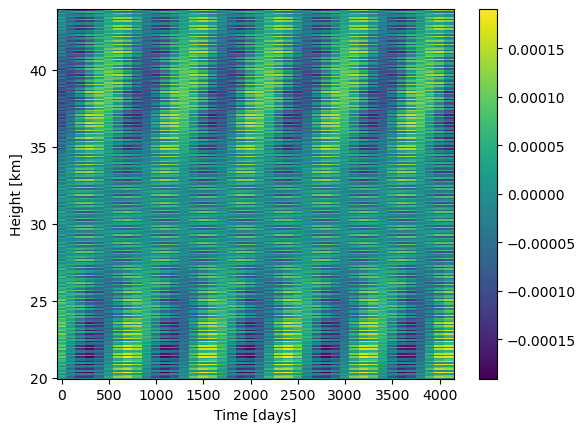

In [32]:
TIMESH,ZMESH= np.meshgrid(time_array,z_array)


plt.figure()
plt.pcolor(TIMESH/3600/24,ZMESH/1000,wbar_save[:,0,:])
plt.ylabel('Height [km]')
plt.xlabel('Time [days]')
plt.colorbar()

Text(0.5, 1.0, 'Constant D')

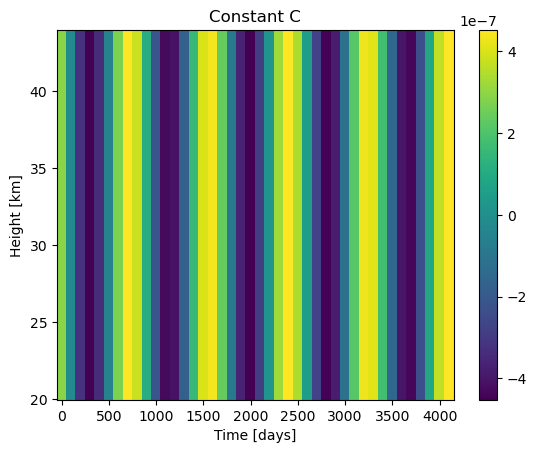

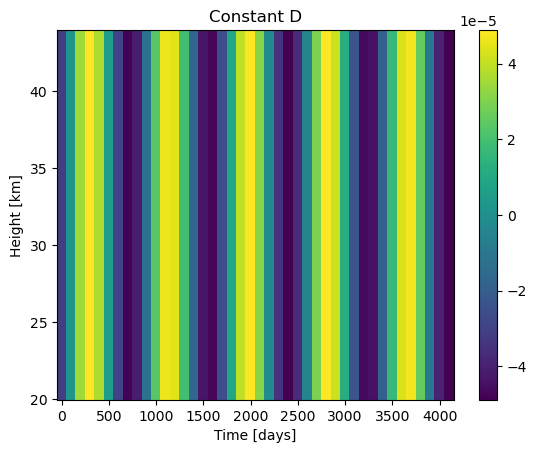

In [33]:


plt.figure()
plt.pcolor(TIMESH/3600/24,ZMESH/1000,C_save[:,0,:])
plt.ylabel('Height [km]')
plt.xlabel('Time [days]')
plt.colorbar()
plt.title('Constant C')

plt.figure()
plt.pcolor(TIMESH/3600/24,ZMESH/1000,D_save[:,0,:])
plt.ylabel('Height [km]')
plt.xlabel('Time [days]')
plt.colorbar()
plt.title('Constant D')